<a href="https://colab.research.google.com/github/cm06/EMSC2010-Individual-Project-Exploring-potential-effects-of-the-upcoming-El-Nino-event/blob/main/Individual_Project_Exploring_potential_effects_of_the_upcoming_El_Nino_event.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Charlotte Miller Individual Project:

---



What can we expect from the 2026 El Nino event in regards to coral bleaching?

Dataset info: My chosen data set was the Global Coral Bleaching Database which was derived from the NOAA National Centers for Environmental Information.

Link to data website: https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:0228498

Link to metadata: https://catalog.data.gov/harvest_record/c35a0a32-1df7-4618-92cc-4a4c8197e082/raw

Link to data (excel file): https://1drv.ms/x/c/26adf2a591d32605/IQDkh7HQLnNdQZDa4woCrl-6AeBTjb5IHE68nGFeP888q6I?e=8yThVI&nav=MTVfezQxNEI4NEE1LTk2OEItNEI3MC1BNTZBLTRCOTk2NUYxRTBFQn0

First, I decided to look over my chosen dataset to see what I could reasonably analyse. I ended up deciding to investigate the question on what the trend of coral bleaching over time would be because an individual hearing about climate change and coral bleaching could be inclined to think that the trend would increase over time.

First step was to upload the chosen dataset and investigate it in order to make sure there were no unusable values or outliers. I did this using df.head and df.info as it would help me become familiar with the columns I would be working with and whether I would need to convert any of the data.

In [28]:
#Upload dataset
import pandas as pd
df = pd.read_excel('Global_Coral_Bleaching_Database.xlsx')
df.head()

,RECORD_ID,COUNTRY,LOCATION,SITE_NAME,LATITUDE,LONGITUDE,DAY,MONTH,YEAR,DEPTH,...,PERCENT_MORTALITY,SURVEY_TYPE,SOURCE,CITATION,COMMENTS,DATA_POINT_OF_CONTACT,POC_E-MAIL_ADDRESS,CORAL_REGIONS,MIN_PERCENT_BLEACHED,MAX_PERCENT_BLEACHED
0,100001,Jamaica,NaN,NaN,17.898040,-76.814140,NaN,NaN,1963,NaN,...,NaN,NaN,ReefBase,NaN,"Some of the surviving corals bleached (Goreau,...",NaN,NaN,Caribbean/GoM,NaN,NaN
1,100002,Colombia,Providencia Island (Isla de Providencia),NaN,13.358333,-81.383333,NaN,NaN,1969,1-20m,...,NaN,NaN,ReefBase,NaN,NaN,NaN,NaN,Caribbean/GoM,NaN,NaN
2,100003,Puerto Rico,Puerto Rico,NaN,17.866667,-66.433333,NaN,NaN,1969,NaN,...,NaN,NaN,ReefBase,NaN,An intensive and extensive bleaching event occ...,NaN,NaN,Caribbean/GoM,NaN,NaN
3,100004,United States,Florida,Middle Sambo Reef,24.490000,-81.675000,NaN,NaN,1973,NaN,...,NaN,NaN,ReefBase,NaN,Millepora complanata showed the greatest incid...,NaN,NaN,Caribbean/GoM,NaN,NaN
4,100007,British Virgin Islands,Anegada,NaN,18.733333,-64.316667,NaN,NaN,1979,NaN,...,NaN,NaN,ReefBase,NaN,Actual cause of bleaching is not known. Partia...,NaN,NaN,Caribbean/GoM,NaN,NaN


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33244 entries, 0 to 33243
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RECORD_ID              33244 non-null  object 
 1   COUNTRY                33244 non-null  object 
 2   LOCATION               32414 non-null  object 
 3   SITE_NAME              24528 non-null  object 
 4   LATITUDE               33244 non-null  float64
 5   LONGITUDE              33244 non-null  float64
 6   DAY                    19077 non-null  object 
 7   MONTH                  32660 non-null  float64
 8   YEAR                   33244 non-null  int64  
 9   DEPTH                  14034 non-null  object 
 10  PERCENT_BLEACHED       30845 non-null  object 
 11  PERCENT_MORTALITY      10940 non-null  object 
 12  SURVEY_TYPE            20527 non-null  object 
 13  SOURCE                 32550 non-null  object 
 14  CITATION               7721 non-null   object 
 15  CO

The next step was to upload the packages I would need.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn
from scipy import stats
import pymc as pm
import arviz as az

The first step to figuring out what the trend of coral bleaching over time was to convert the PERCENT_BLEACHED data column. This was because df.info showed the column as an object type, which means it would need to be converted to a numeric format. I did this through the pd.to_numeric function and added errors='coerce' to turn any problematic values into 'NaN' (Not a Number).

In [31]:
df['PERCENT_BLEACHED'] = pd.to_numeric(df['PERCENT_BLEACHED'], errors='coerce')

# Drop rows with NaN values in 'PERCENT_BLEACHED' or 'YEAR' for plotting purposes
df_plot = df.dropna(subset=['PERCENT_BLEACHED', 'YEAR']).copy()

In [32]:
df[['YEAR',
    'PERCENT_BLEACHED',
    'DEPTH']].describe()

,YEAR,PERCENT_BLEACHED
count,33244.000000,26084.000000
mean,2010.732734,14.097517
std,6.215800,24.172017
min,1963.000000,0.000000
25%,2006.000000,0.000000
50%,2014.000000,1.000000
75%,2016.000000,17.400000
max,2021.000000,100.000000


The next step was to investigate the relationship that will show the trend of coral bleaching over the years of the dataset. This relationship was the Average Percent Bleached vs Year as it would create a linear relationship for me to analyse.

First, I calculated the annual average bleaching percentage by grouping the df_plot DataFrame by 'YEAR' and calculating the mean 'PERCENT_BLEACHED' for each year to get a clearer trend of average bleaching severity over time.

In [33]:
df_annual_avg_bleaching = df_plot.groupby('YEAR')['PERCENT_BLEACHED'].mean().reset_index()
print(df_annual_avg_bleaching.head())


   YEAR  PERCENT_BLEACHED
0  1982         16.500000
1  1983         61.319268
2  1986         16.630000
3  1987         17.902941
4  1988         19.233162


Next, I visualised the trend ('PERCENT_BLEACHED') by ('YEAR') using a linegraph, which was chosen due to its ability to help visually identify any increasing or decreasing trends in bleaching severity.

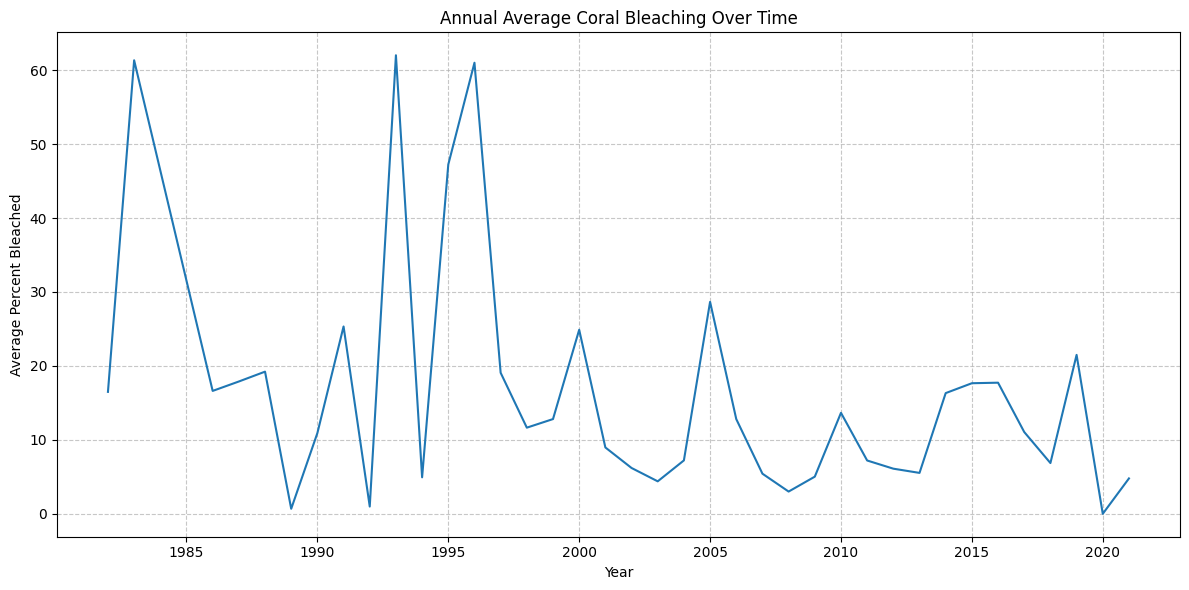

In [34]:
# Ensure df_annual_avg_bleaching is defined for this plot
df_annual_avg_bleaching = df_plot.groupby('YEAR')['PERCENT_BLEACHED'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='YEAR', y='PERCENT_BLEACHED', data=df_annual_avg_bleaching)
plt.title('Annual Average Coral Bleaching Over Time')
plt.xlabel('Year')
plt.ylabel('Average Percent Bleached')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

As you can see from the generated linegraph above, the trend of the average percent of bleached coral over time is declining. However, in order to further investigate this, I chose to create a second graph with a regression line.

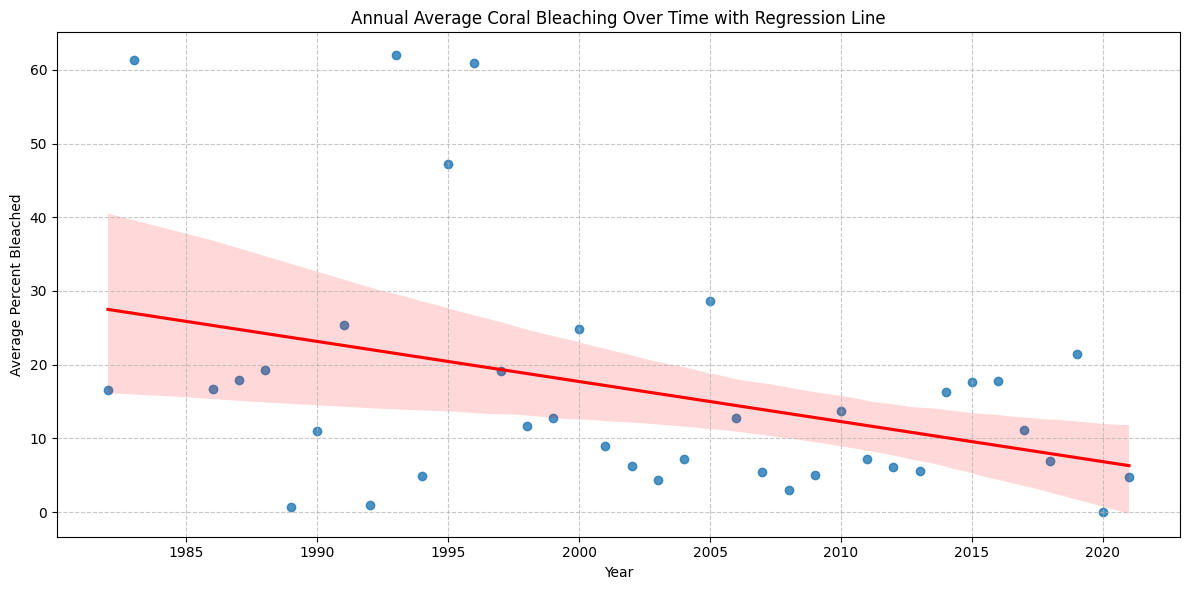

In [35]:
plt.figure(figsize=(12, 6))
sns.regplot(x='YEAR', y='PERCENT_BLEACHED', data=df_annual_avg_bleaching, line_kws={'color':'red'})
plt.title('Annual Average Coral Bleaching Over Time with Regression Line')
plt.xlabel('Year')
plt.ylabel('Average Percent Bleached')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

It is due to this figure and regression line that it can be clearly seen that the average percent of coral bleaching is declining over time. There are multiple reasons as to why this may be, one of which could be due to the large percentage of bleaching that occured in the earlier years have led to less unbleached coral to bleach in recent years. Another could be that coral have evolved other time and have become less suscectable to bleaching.

The last step I took to fully investigate the trend of coral bleaching over time was to conduct a linear regression using the annual average 'PERCENT_BLEACHED' as the dependent variable and 'YEAR' as the independent variable. This will quantify the trend and assess its statistical significance to answer whether bleaching severity has increased over time. This process including importing the package statsmodels.formula.api, defining the model formula, fitting the OLS model using df_annual_avg_bleaching, and printing the model summary.

In [36]:
import statsmodels.formula.api as smf

# Fit the linear regression model
model = smf.ols('PERCENT_BLEACHED ~ YEAR', data=df_annual_avg_bleaching).fit()

# Print the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       PERCENT_BLEACHED   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     6.029
Date:                Tue, 02 Jun 2026   Prob (F-statistic):             0.0190
Time:                        03:23:12   Log-Likelihood:                -156.34
No. Observations:                  38   AIC:                             316.7
Df Residuals:                      36   BIC:                             320.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1105.1550    443.415      2.492      0.0

Analysis:

The coefficient for 'YEAR' is -0.5437, with a p-value of 0.019. This is a statistically significant negative coefficien as it implies that, on average, for every one-year increase, the annual average 'PERCENT_BLEACHED' decreases by approximately 0.54 percentage points. This suggests a slight but statistically significant decrease in the average percent bleached over the years covered by the data.

The p-value (probability value) is a measure of the strength of evidence against the null hypothesis. The null hypothesis is a statement that there is no effect or no relationship between variables.

*   **How to interpret a p-value:**
    *   **Small p-value (typically ≤ 0.05)**: Suggests that the observed data is unlikely to have occurred by random chance if the null hypothesis were true. This leads to the rejection of the null hypothesis, implying that there is statistically significant evidence of an effect or relationship.
    *   **Large p-value (typically > 0.05)**: Suggests that the observed data is likely to have occurred by random chance if the null hypothesis were true. This means there isn't enough evidence to reject the null hypothesis, and the effect or relationship observed might just be due to random variation.

**Interpretation in this context:**

In our linear regression models:
*   For **coral bleaching**, the p-value for 'YEAR' was **0.019**. Since this is less than 0.05, it indicates that the negative relationship between 'YEAR' and 'PERCENT_BLEACHED' is statistically significant. Meaning, We can be reasonably confident that the observed slight decline is not just due to random chance.

Conclusion:

Based on both the visual trend and the linear regression analysis, there is a statistically significant but slight negative trend in the annual average coral bleaching severity over time. Although the R-squared value is low, indicating that other factors contribute more significantly to bleaching variability, the regression model suggests a general tendency for the average bleaching percentage to decrease slightly each year. The visual plot also supports this by not showing a clear increasing trend, but rather fluctuations around a potentially slowly declining average.

Next, I was interested in investigating the relationship between the mortality data and year as I thought it would be benefictual to analyse any increasing or decreasing trends like I did with Annual Average Bleaching.

To do this, I first converted the PERCENT_MORTALITY column to a numeric type as I did with the Annual Average Bleaching. I then created a new DataFrame df_mortality_plot that would only contains rows where both PERCENT_MORTALITY and YEAR are not NaN, ensuring a clean dataset for subsequent plotting and analysis.

In [37]:
df['PERCENT_MORTALITY'] = pd.to_numeric(df['PERCENT_MORTALITY'], errors='coerce')
df_mortality_plot = df.dropna(subset=['PERCENT_MORTALITY', 'YEAR']).copy()

print("First 5 rows of df_mortality_plot:")
print(df_mortality_plot.head())

First 5 rows of df_mortality_plot:
    RECORD_ID              COUNTRY         LOCATION SITE_NAME  LATITUDE  \
34     100042           Costa Rica      Cano Island       NaN    8.7333   
45     100059           Costa Rica     Cocos Island  Presidio    5.5500   
114    100148              Bahamas  Rainbow Gardens       NaN   23.7400   
115    100149              Bahamas      South Perry       NaN   23.7450   
144    100198  U.S. Virgin Islands        St. Croix  Cane Bay   17.6840   

     LONGITUDE  DAY  MONTH  YEAR  DEPTH  ...  PERCENT_MORTALITY  \
34    -83.8833  NaN    NaN  1982    NaN  ...              0.500   
45    -87.0600  NaN    1.0  1983    NaN  ...              0.000   
114   -76.0660  NaN    9.0  1987   3-5m  ...              0.003   
115   -76.0810  NaN    9.0  1987   3-5m  ...              0.005   
144   -64.7390  NaN    9.0  1987  8-10m  ...              0.009   

                                       SURVEY_TYPE  \
34                                             NaN   
45 

Next, I calculated the annual average mortality by grouping the df_mortality_plot DataFrame by 'YEAR' and calculating the mean 'PERCENT_MORTALITY' for each year to get a clearer trend of average mortality over time

In [38]:
df_annual_avg_mortality = df_mortality_plot.groupby('YEAR')['PERCENT_MORTALITY'].mean().reset_index()
print(df_annual_avg_mortality.head())

   YEAR  PERCENT_MORTALITY
0  1982           0.500000
1  1983           0.000000
2  1987           0.017000
3  1988           0.031529
4  1989           0.000000


Next, I visualised the trend ('PERCENT_MORTALITY') against ('YEAR') using a linegraph, which was chosen due to its ability to help visually identify any increasing or decreasing trends in mortality.

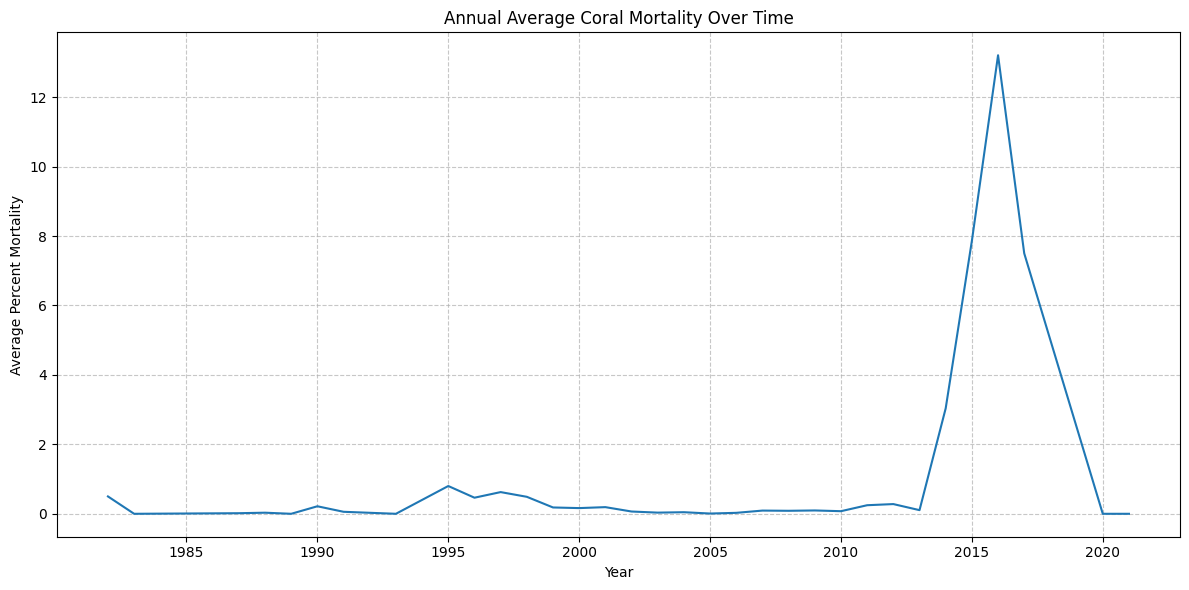

In [39]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='YEAR', y='PERCENT_MORTALITY', data=df_annual_avg_mortality)
plt.title('Annual Average Coral Mortality Over Time')
plt.xlabel('Year')
plt.ylabel('Average Percent Mortality')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

As can be seen from the lineplot above, there were peaks in mortality in the years 1995 and 2016. Both of these peaks were directly correlated to climate events, the largest peak in 2016 being the last El Nino event.

The 1995 climate event was caused by higher-than-normal summer sea temperatures. Link: https://www.redalyc.org/pdf/449/44911590008.pdf

Another peak can be seen in 1998 which correlates to the heatwave that took place that year. Link: https://www.aims.gov.au/research-topics/environmental-issues/coral-bleaching/coral-bleaching-events

The last peak, and the largest one at that was in 2015/2016 was where record ocean temperatures led to widespread coral bleaching. This was part of the third global bleaching event declared by the National Oceanic and Atmospheric Administration (NOAA) in 2015. This was also the last El Nino, which is a climatological phenomenon characterized by unusually warm ocean conditions along the tropical west coast of South America. Links: https://www.bom.gov.au/climate/updates/articles/a018.shtml

https://www.britannica.com/science/El-Nino

The last step I took to fully investigate the trend of coral mortality over time was to conduct a linear regreesion using the annual average 'PERCENT_MORTALITY' as the dependent variable and 'YEAR' as the independent variable. This will quantify the trend and assess its statistical significance. This process including importing the package statsmodels.formula.api, fitting the OLS model using, df_annual_avg_mortality, and printing the model summary.

In [40]:
import statsmodels.formula.api as smf

# Fit the linear regression model
mortality_model = smf.ols('PERCENT_MORTALITY ~ YEAR', data=df_annual_avg_mortality).fit()

# Print the model summary
print(mortality_model.summary())

                            OLS Regression Results                            
Dep. Variable:      PERCENT_MORTALITY   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     5.934
Date:                Tue, 02 Jun 2026   Prob (F-statistic):             0.0208
Time:                        03:23:12   Log-Likelihood:                -78.204
No. Observations:                  33   AIC:                             160.4
Df Residuals:                      31   BIC:                             163.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -211.4654     87.267     -2.423      0.0

Analysis:

**Coefficient for YEAR:** The coefficient for 'YEAR' is **0.1062**, with a p-value of **0.021**. This indicates a statistically significant *positive* coefficient. In practical terms, this suggests that, on average, for every one-year increase, the annual average 'PERCENT_MORTALITY' increases by approximately 0.11 percentage points. This finding presents a notable contrast to the slight negative trend observed in average coral bleaching.


**Relationship to Narrative and Visual Trends:**

While the regression model suggests a slight overall increase in average coral mortality over time, the visual representation of the 'Annual Average Coral Mortality Over Time' provides a more complete picture. This line plot clearly shows that the most significant increases in mortality are not gradual, but rather dramatic, episodic peaks coinciding with major climate events, such as the 1995 event, and most notably the 2014-2016 El Nino. These acute events appear to drive the majority of the observed mortality, overshadowing the slow, continuous increase suggested by the linear regression.

Therefore, while there may be a subtle underlying trend of increasing mortality, the severe and rapid spikes during specific climate events like El Nino are the dominant feature. This implies that a future El Nino event, such as in 2026, is likely to cause substantial and abrupt increases in coral mortality, rather than a gradual rise based solely on the year-on-year trend.

Next, in order to fully explore the chosen dataset and further the exploration of average coral bleaching and morality in large climate events, I chose to plot the coral regions against both Average Bleaching and Mortality.

First, I calculated the average bleaching per coral region by grouping the df_plot DataFrame by 'CORAL_REGIONS' and calculated the mean of 'PERCENT_BLEACHED'.

In [41]:
df_regional_avg_bleaching = df_plot.groupby('CORAL_REGIONS')['PERCENT_BLEACHED'].mean().reset_index()
print(df_regional_avg_bleaching.head())

   CORAL_REGIONS  PERCENT_BLEACHED
0  Caribbean/GoM         18.904012
1            GBR          7.929443
2     Other Reef         11.001110
3    West-Indian         10.655253


Next, I identified the top bleaching regions by sorting the calculated average bleaching percentages by CORAL_REGIONS in descending order to easily identify the regions with the highest average bleaching severity.

In [42]:
df_top_bleaching_regions = df_regional_avg_bleaching.sort_values(by='PERCENT_BLEACHED', ascending=False).reset_index(drop=True)
print(df_top_bleaching_regions.head())

   CORAL_REGIONS  PERCENT_BLEACHED
0  Caribbean/GoM         18.904012
1     Other Reef         11.001110
2    West-Indian         10.655253
3            GBR          7.929443


Lastly I created a bar chart to display the average 'PERCENT_BLEACHED' for each 'CORAL_REGIONS'.

/tmp/ipykernel_2690/1540586261.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CORAL_REGIONS', y='PERCENT_BLEACHED', data=df_top_bleaching_regions, palette='viridis')


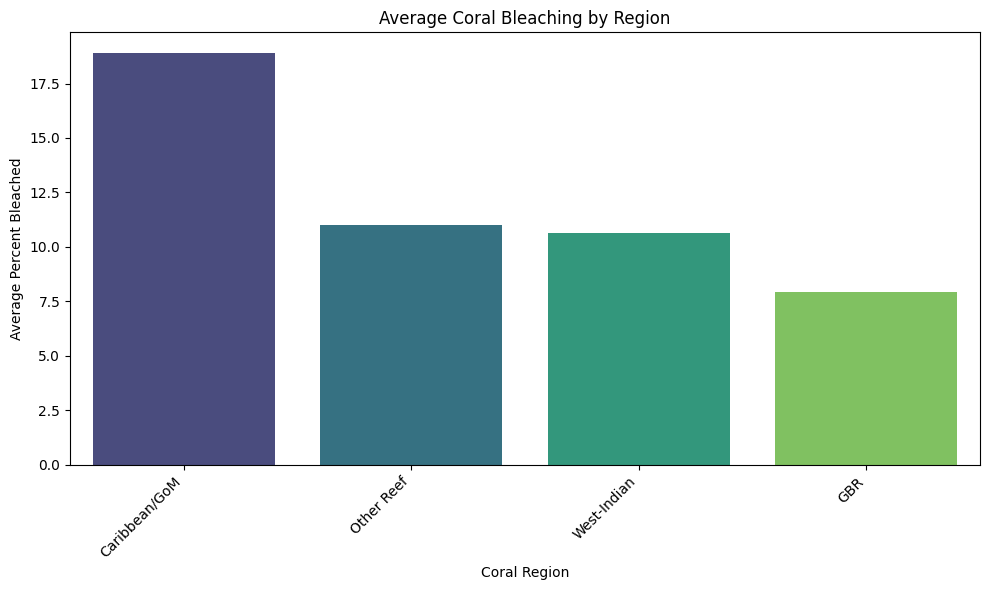

In [43]:
plt.figure(figsize=(10, 6))
sns.barplot(x='CORAL_REGIONS', y='PERCENT_BLEACHED', data=df_top_bleaching_regions, palette='viridis')
plt.title('Average Coral Bleaching by Region')
plt.xlabel('Coral Region')
plt.ylabel('Average Percent Bleached')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Analysis:

The 'Caribbean/GoM' (Caribbean/Gulf of Mexico) region exhibits the highest average bleaching percentage, at approximately 18.90%. This is followed by 'Other Reef' (11.00%), 'West-Indian' (10.66%), and 'GBR' (Great Barrier Reef) (7.93%).

I then did the same for Mortality per region.

First, I calculated the average bleaching per coral region by grouping the df__mortality_plot DataFrame by 'CORAL_REGIONS' and calculating the mean of 'PERCENT_MORTALITY'.

In [44]:
df_regional_avg_mortality = df_mortality_plot.groupby('CORAL_REGIONS')['PERCENT_MORTALITY'].mean().reset_index()
print(df_regional_avg_mortality.head())

   CORAL_REGIONS  PERCENT_MORTALITY
0  Caribbean/GoM           1.161004
1            GBR           6.591317
2     Other Reef          10.087176
3    West-Indian           5.287853


Next, I identified the top mortality regions by sorting the df_regional_avg_mortality DataFrame by 'PERCENT_MORTALITY' in descending order to identify the regions with the highest average mortality.

In [45]:
df_top_mortality_regions = df_regional_avg_mortality.sort_values(by='PERCENT_MORTALITY', ascending=False).reset_index(drop=True)
print(df_top_mortality_regions.head())

   CORAL_REGIONS  PERCENT_MORTALITY
0     Other Reef          10.087176
1            GBR           6.591317
2    West-Indian           5.287853
3  Caribbean/GoM           1.161004


Lastly I created a bar chart to display the average 'PERCENT_MORTALITY' for each 'CORAL_REGIONS'.

/tmp/ipykernel_2690/65471002.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CORAL_REGIONS', y='PERCENT_MORTALITY', data=df_top_mortality_regions, palette='viridis')


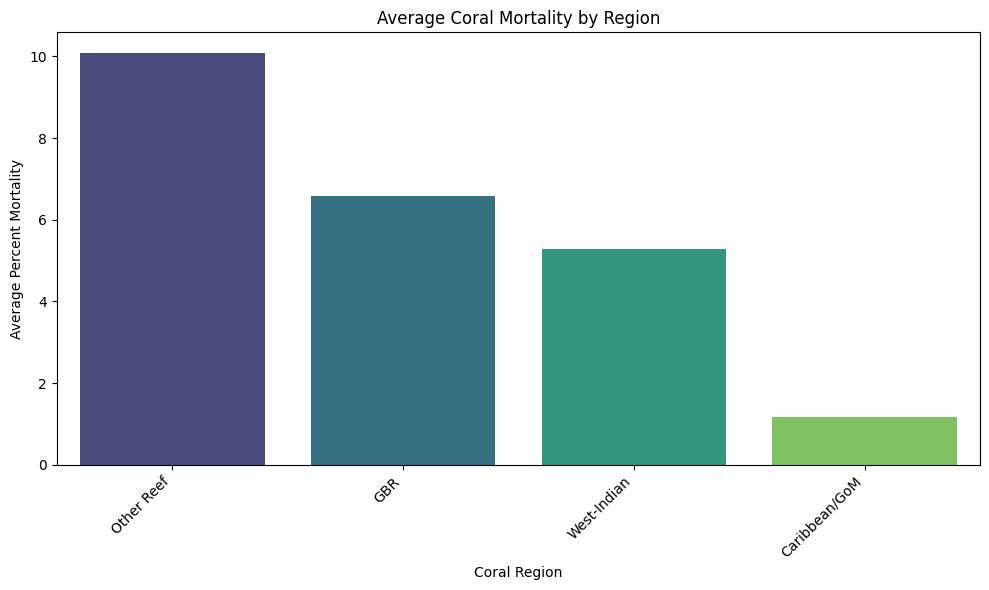

In [46]:
plt.figure(figsize=(10, 6))
sns.barplot(x='CORAL_REGIONS', y='PERCENT_MORTALITY', data=df_top_mortality_regions, palette='viridis')
plt.title('Average Coral Mortality by Region')
plt.xlabel('Coral Region')
plt.ylabel('Average Percent Mortality')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Analysis:

Other Reef: This region shows the highest average coral mortality at approximately 10.09%.
GBR (Great Barrier Reef): Follows with an average mortality of about 6.59%.
West-Indian: Has an average mortality of approximately 5.29%.
Caribbean/GoM (Caribbean/Gulf of Mexico): This region exhibits the lowest average mortality among the listed regions, at about 1.16%.
Comparison with Regional Coral Bleaching Hotspots: Earlier in the analysis, we identified the regional bleaching hotspots from df_top_bleaching_regions:

Caribbean/GoM: Had the highest average bleaching percentage at approximately 18.90%.
Other Reef: Showed an average bleaching of 11.00%.
West-Indian: Recorded 10.66% average bleaching.
GBR: Had the lowest average bleaching at 7.93%.

Inverse Relationship for Caribbean/GoM: The 'Caribbean/GoM' region, which was identified as the primary hotspot for coral bleaching, shows the lowest average coral mortality. This is a significant finding, suggesting that while corals in this region might be more prone to bleaching, they might also exhibit higher resilience or recovery rates, or perhaps the bleaching events are not as severe to lead to high mortality. It could also indicate that bleaching events in this region do not consistently lead to high mortality.
Other Reef's Dual Vulnerability: The 'Other Reef' region stands out as a hotspot for both high average bleaching (second highest at 11.00%) and the highest average mortality (10.09%). This suggests that corals in this region are not only prone to bleaching but also experience high mortality as a direct consequence of these events, or are generally less resilient to stressors.
GBR's Mortality vs. Bleaching: The Great Barrier Reef (GBR) had the lowest average bleaching percentage (7.93%) among the regions analyzed but shows the second-highest average mortality (6.59%). This indicates that even less frequent or less severe bleaching events in the GBR might lead to higher mortality, possibly due to other environmental stressors or a lower capacity for recovery compared to the Caribbean/GoM.
West-Indian Region: This region shows a moderate level for both average bleaching (10.66%) and average mortality (5.29%), suggesting a consistent vulnerability across both metrics.

Conclusion:
The analysis reveals that regional patterns of coral bleaching severity do not always directly correlate with regional coral mortality rates. While some regions like 'Other Reef' show high vulnerability in both aspects, 'Caribbean/GoM' presents a unique case with high bleaching but low mortality, and the GBR shows relatively lower bleaching but higher mortality. This underscores the complex dynamics of coral health, where factors beyond just the initial bleaching event, such as resilience, duration of stress, and other environmental conditions, play a crucial role in determining eventual coral mortality.

Next, I decided to pull the specific coral region (GBR (Great Barrier Reef)) data out and compare it with the rest of the world data in order to investigate what we could expect in the next upcoming El Nino.

I first did this with Average Percent Bleaching, first I filtered the data for just GBR, then I calculated the annual average bleaching for GBR and then created a visual line plot.

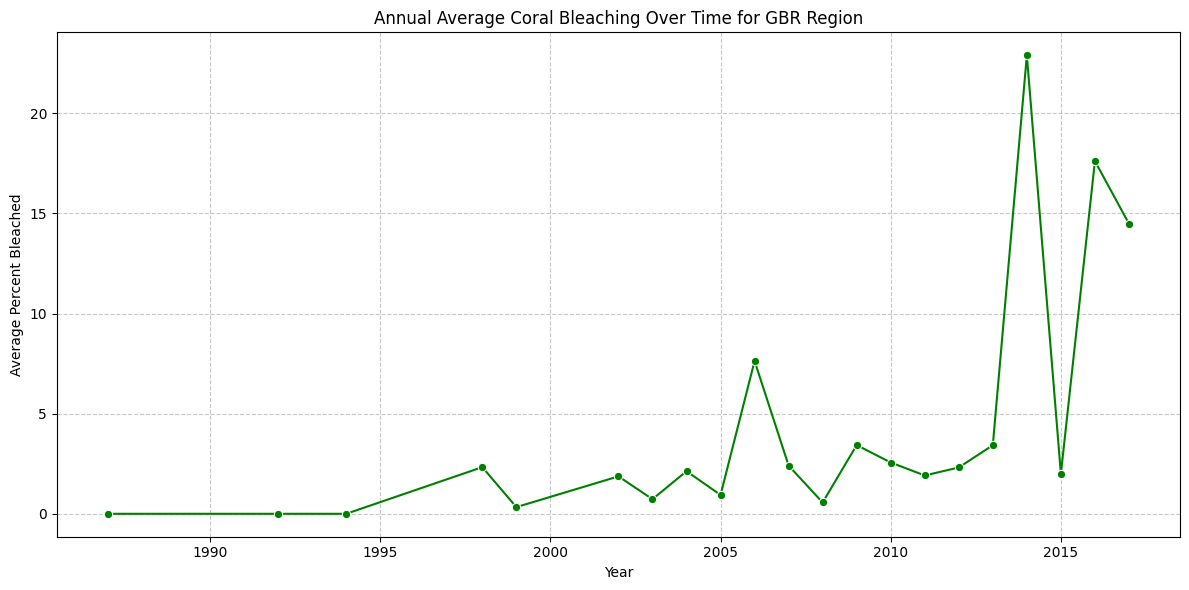

In [47]:
# Filter df_plot for GBR region
df_gbr = df_plot[df_plot['CORAL_REGIONS'] == 'GBR']

# Calculate annual average bleaching for GBR
df_gbr_annual_avg_bleaching = df_gbr.groupby('YEAR')['PERCENT_BLEACHED'].mean().reset_index()

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='YEAR', y='PERCENT_BLEACHED', data=df_gbr_annual_avg_bleaching, marker='o', color='green')
plt.title('Annual Average Coral Bleaching Over Time for GBR Region')
plt.xlabel('Year')
plt.ylabel('Average Percent Bleached')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

As you can see, there are three clear peaks in years that directly related to climate events that would have caused large amounts of coral bleaching. The first was 1998 where there were higher-than-normal summer sea temperatures. The second was in January and February 2006, where a small localised bleaching event took place in the southern Reef, especially around the inshore Keppel Islands. Link: https://www.aims.gov.au/research-topics/environmental-issues/coral-bleaching/coral-bleaching-events. Finally the last ones were in 2014-2016 which was the last El Nino event, something that would have caused mass bleaching in the Great Barrier Reef.

Next, I compared Annual Average Coral Bleaching for GBR vs. Rest of World by filtering the df_plot for the rest of world (excluding GBR region), calculating the annual average bleaching for this, renaming the columns for clarity, combining the two DataFrames and creating a comparative line plot.

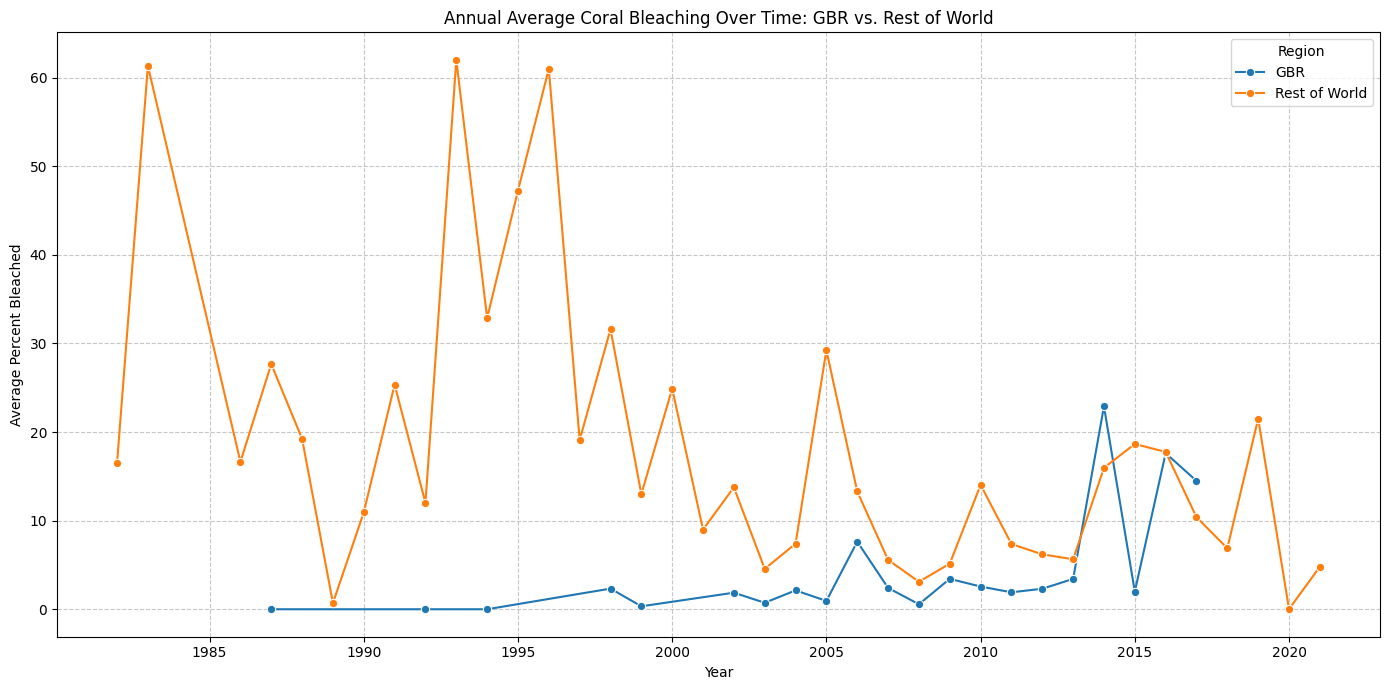

In [48]:
# Filter df_plot for 'Rest of World' (excluding GBR region)
df_row = df_plot[df_plot['CORAL_REGIONS'] != 'GBR']

# Calculate annual average bleaching for 'Rest of World'
df_row_annual_avg_bleaching = df_row.groupby('YEAR')['PERCENT_BLEACHED'].mean().reset_index()

# Rename columns for clarity when combining
df_gbr_annual_avg_bleaching['Region'] = 'GBR'
df_gbr_annual_avg_bleaching.rename(columns={'PERCENT_BLEACHED': 'Avg_Percent_Bleached'}, inplace=True)

df_row_annual_avg_bleaching['Region'] = 'Rest of World'
df_row_annual_avg_bleaching.rename(columns={'PERCENT_BLEACHED': 'Avg_Percent_Bleached'}, inplace=True)

# Combine the two DataFrames
df_combined_bleaching = pd.concat([df_gbr_annual_avg_bleaching, df_row_annual_avg_bleaching])

# Create the comparative line plot
plt.figure(figsize=(14, 7))
sns.lineplot(x='YEAR', y='Avg_Percent_Bleached', hue='Region', data=df_combined_bleaching, marker='o')
plt.title('Annual Average Coral Bleaching Over Time: GBR vs. Rest of World')
plt.xlabel('Year')
plt.ylabel('Average Percent Bleached')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

I also created a cross plot for better visualisation of the Annual Average Coral Bleaching for GBR vs. Rest of World.

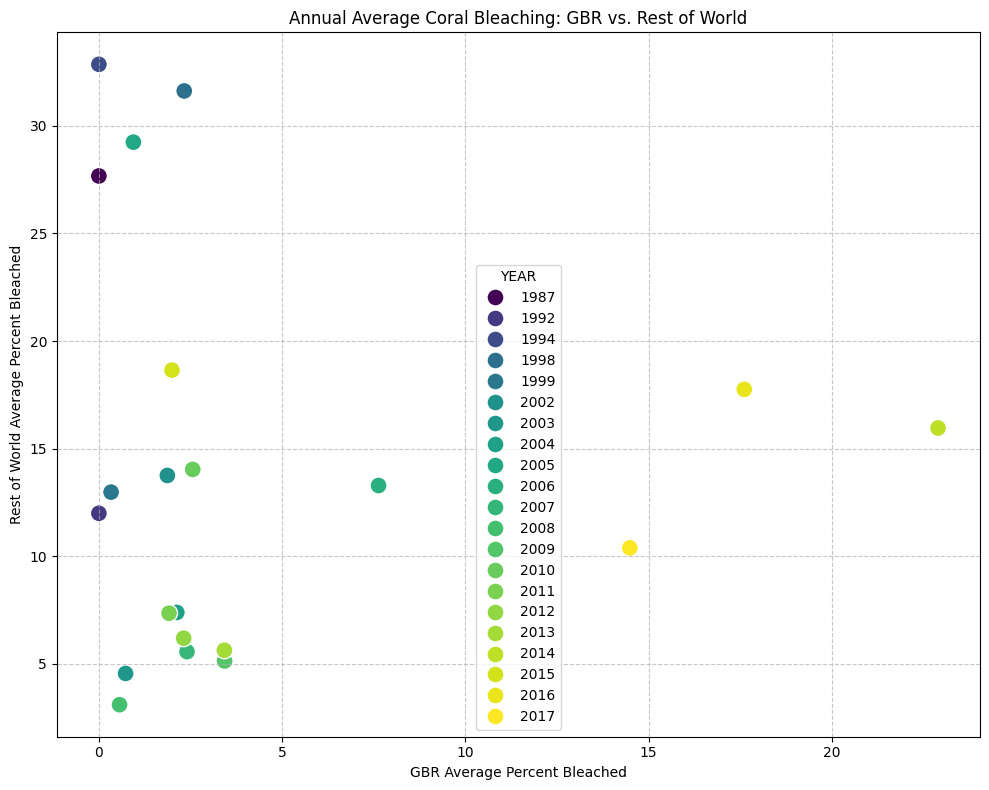

In [55]:
# Merge the GBR and Rest of World annual average bleaching dataframes
df_cross_plot = pd.merge(
    df_gbr_annual_avg_bleaching.rename(columns={'Avg_Percent_Bleached': 'GBR_Avg_Bleaching'}),
    df_row_annual_avg_bleaching.rename(columns={'Avg_Percent_Bleached': 'ROW_Avg_Bleaching'}),
    on='YEAR',
    how='inner'
)

# Create the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='GBR_Avg_Bleaching',
    y='ROW_Avg_Bleaching',
    data=df_cross_plot,
    hue='YEAR',
    size='YEAR',
    sizes=(150, 150), # Adjust marker size based on year
    palette='viridis', # Use a colormap for year
    legend='full'
)

plt.title('Annual Average Coral Bleaching: GBR vs. Rest of World')
plt.xlabel('GBR Average Percent Bleached')
plt.ylabel('Rest of World Average Percent Bleached')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

As you can see, the Rest of World Average Percent Bleached was higher in the earlier years of the dataset and lowered in the latest while GBR Average Percent Bleached increased in the latest years.

I also decided to plot all four of the regions against each other for Average Percent Bleaching in order to better visualise and see trends.

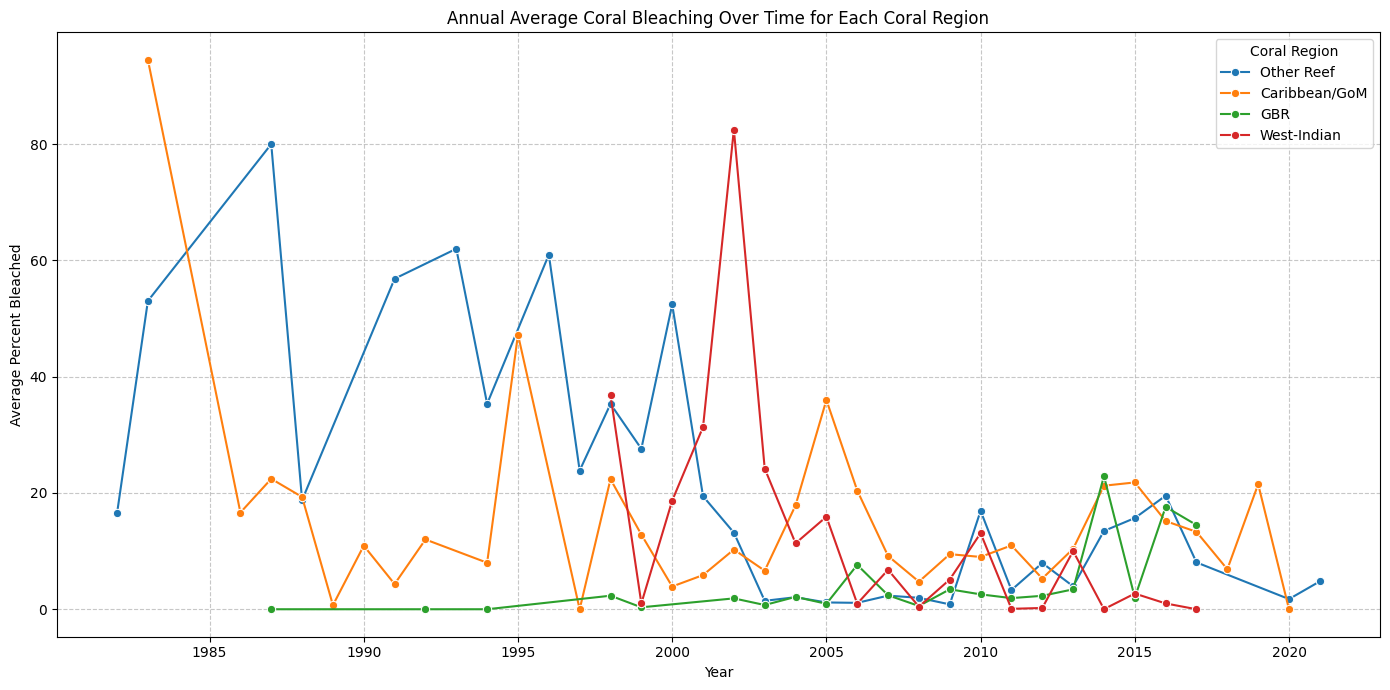

In [50]:
# Calculate annual average bleaching for all regions
df_all_regions_annual_avg_bleaching = df_plot.groupby(['YEAR', 'CORAL_REGIONS'])['PERCENT_BLEACHED'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='YEAR', y='PERCENT_BLEACHED', hue='CORAL_REGIONS', data=df_all_regions_annual_avg_bleaching, marker='o')
plt.title('Annual Average Coral Bleaching Over Time for Each Coral Region')
plt.xlabel('Year')
plt.ylabel('Average Percent Bleached')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Coral Region')
plt.tight_layout()
plt.show()

As you can see, all four reef regions had jumps in the last El Nino and the other three had lines that seemed to deline towards the end while the GBR jumped up towards the end.

I then chose to do the same thing with mortailty, first creating an Annual Average Coral Mortality Over Time line plot for the GBR Region.

## Annual Average Coral Mortality Over Time for the GBR Region

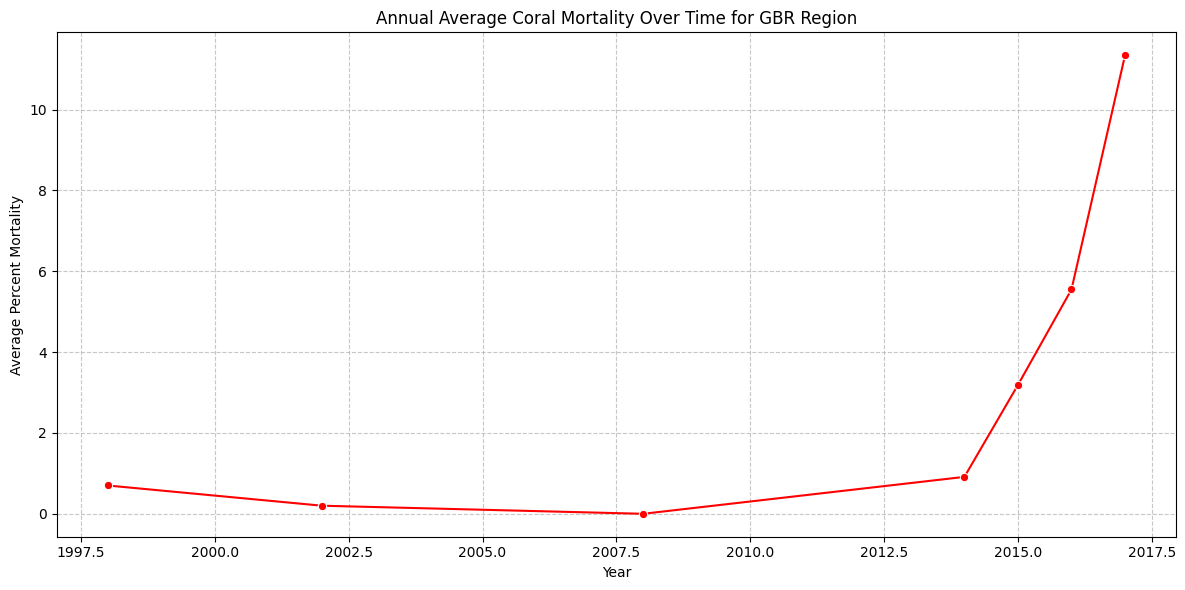

In [51]:
# Filter df_mortality_plot for GBR region
df_gbr_mortality = df_mortality_plot[df_mortality_plot['CORAL_REGIONS'] == 'GBR']

# Calculate annual average mortality for GBR
df_gbr_annual_avg_mortality = df_gbr_mortality.groupby('YEAR')['PERCENT_MORTALITY'].mean().reset_index()

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='YEAR', y='PERCENT_MORTALITY', data=df_gbr_annual_avg_mortality, marker='o', color='red')
plt.title('Annual Average Coral Mortality Over Time for GBR Region')
plt.xlabel('Year')
plt.ylabel('Average Percent Mortality')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

As you can see the average percent mortality for the GBR jumped up significantly within the last El Nino event (2014-2016).

I then did a comparative analysis of annual average coral mortality for GBR vs. Rest of World by filtering the df_mortality_plot for the rest of world (excluding GBR region), calculating the annual average bleaching for this, renaming the columns for clarity, combining the two DataFrames and creating a comparative line plot.

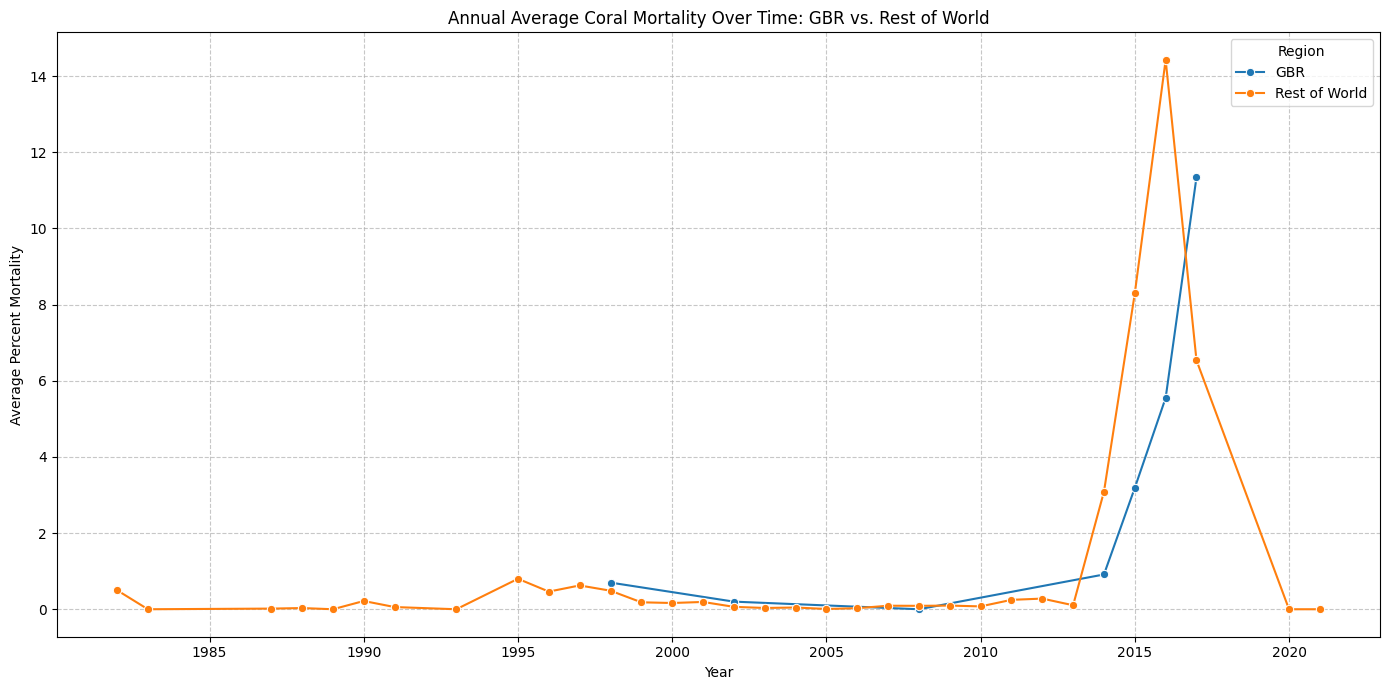

In [52]:
# Filter df_mortality_plot for 'Rest of World' (excluding GBR region)
df_row_mortality = df_mortality_plot[df_mortality_plot['CORAL_REGIONS'] != 'GBR']

# Calculate annual average mortality for 'Rest of World'
df_row_annual_avg_mortality = df_row_mortality.groupby('YEAR')['PERCENT_MORTALITY'].mean().reset_index()

# Rename columns for clarity when combining
df_gbr_annual_avg_mortality['Region'] = 'GBR'
df_gbr_annual_avg_mortality.rename(columns={'PERCENT_MORTALITY': 'Avg_Percent_Mortality'}, inplace=True)

df_row_annual_avg_mortality['Region'] = 'Rest of World'
df_row_annual_avg_mortality.rename(columns={'PERCENT_MORTALITY': 'Avg_Percent_Mortality'}, inplace=True)

# Combine the two DataFrames
df_combined_mortality = pd.concat([df_gbr_annual_avg_mortality, df_row_annual_avg_mortality])

# Create the comparative line plot
plt.figure(figsize=(14, 7))
sns.lineplot(x='YEAR', y='Avg_Percent_Mortality', hue='Region', data=df_combined_mortality, marker='o')
plt.title('Annual Average Coral Mortality Over Time: GBR vs. Rest of World')
plt.xlabel('Year')
plt.ylabel('Average Percent Mortality')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

Lastly, I plotted all four coral regions against each other for annual average coral mortality over time.

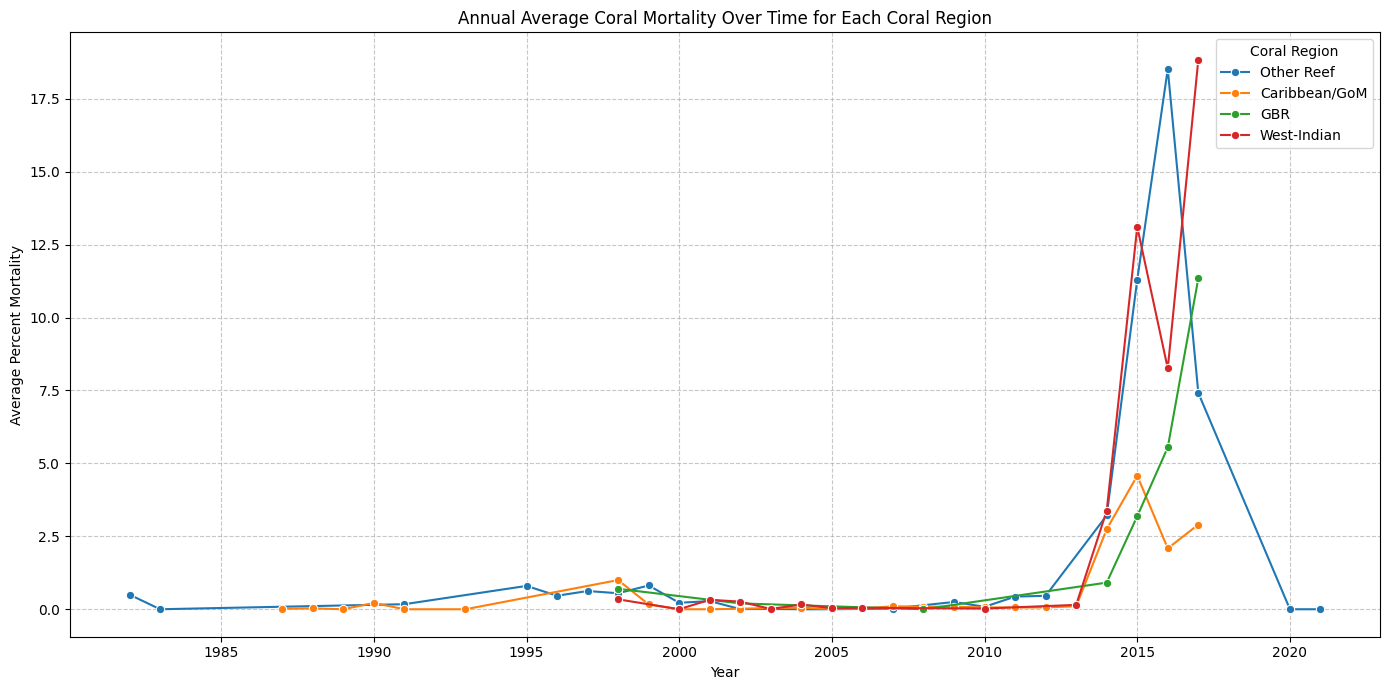

In [53]:
# Calculate annual average mortality for all regions
df_all_regions_annual_avg_mortality = df_mortality_plot.groupby(['YEAR', 'CORAL_REGIONS'])['PERCENT_MORTALITY'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='YEAR', y='PERCENT_MORTALITY', hue='CORAL_REGIONS', data=df_all_regions_annual_avg_mortality, marker='o')
plt.title('Annual Average Coral Mortality Over Time for Each Coral Region')
plt.xlabel('Year')
plt.ylabel('Average Percent Mortality')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Coral Region')
plt.tight_layout()
plt.show()

As can be seen clearly from the graph above, the last El Nino event in 2014-2016 led to large amounts of mortality.

Intepretation in relation to project question (What can we expect from the 2026 El Nino event in regards to coral bleaching?):

To predict what we can expect from the 2026 El Nino event in regards to coral bleaching, it is crucial to synthesize the historical trends of both coral bleaching and mortality observed in this dataset. While the overall linear regression for annual average coral bleaching showed a statistically significant, albeit slight, negative trend over the dataset's years (as seen in the OLS regression summary), this general decline does not mitigate the acute and severe impacts of major climate events like El Nino.

My analysis clearly demonstrates that El Nino events, particularly the last significant one in 2014-2016, correspond to pronounced spikes in both average coral bleaching and subsequent mortality across various regions, with the Great Barrier Reef (GBR) showing particularly high vulnerability during these periods. The line plots of annual average bleaching and mortality reveal that these events are episodic but intense, driving significant deviations from any long-term average trend.

Therefore, despite a weak overall trend in general bleaching, historical data strongly suggests that a 2026 El Nino event would likely trigger widespread and severe coral bleaching. Furthermore, given the observed increases in mortality during past El Nino events, especially in critical regions such as the GBR and 'Other Reefs', it is highly probable that the 2026 El Nino will result in significant coral mortality. The magnitude of this impact could mirror or even exceed previous events, depending on its severity and duration, underscoring the ongoing threat of El Nino events to global coral health.

Limitations:

Several limitations should be considered when interpreting the findings of this project and extrapolating them to future events such as the 2026 El Nino:

1.  **Low Explanatory Power of Linear Regression:** The linear regression models for both annual average bleaching (R-squared = 0.143) and mortality (R-squared = 0.161) indicate that 'YEAR' alone explains a very small proportion of the variance in these metrics. This suggests that while there may be statistically significant long-term trends, other factors not included in this analysis (e.g., specific sea surface temperature anomalies, local environmental stressors, duration and intensity of thermal stress, and the specific characteristics of each El Nino event) are far more influential in driving coral bleaching and mortality.
2.  **Model Assumptions and Stability:** The linear regression models presented issues such as large condition numbers (3.6e+05 for bleaching, 3.76e+05 for mortality), which can suggest multicollinearity or numerical instability in the model, potentially affecting the reliability of the coefficient estimates. Furthermore, the non-normal distribution of residuals in the mortality model (indicated by the Omnibus test and high Skew/Kurtosis values) violates a key assumption of Ordinary Least Squares (OLS) regression, which could impact the validity of the p-values and confidence intervals.
3.  **Data Granularity:** The analysis relies on annual average data. More granular temporal data (e.g., monthly or weekly) could reveal short-term fluctuations and the precise timing and duration of bleaching and mortality events, which are masked when aggregated annually.
4.  **Missing Data:** The dataset contains a substantial number of missing values across various columns, particularly in `DEPTH`, `PERCENT_MORTALITY`, `DAY`, `LOCATION`, `SITE_NAME`, `CITATION`, and `COMMENTS`. The decision to drop rows with `NaN` values for key analysis variables like `PERCENT_BLEACHED` and `PERCENT_MORTALITY` might introduce some bias and reduce the overall representativeness of the analyzed data subset.
5.  **Extrapolation Uncertainty:** Predicting the impact of a 2026 El Nino event based on historical data up to 2021 involves extrapolation. Future oceanic conditions, the specific characteristics of the upcoming El Nino, and potential changes in coral resilience or human intervention efforts could deviate from past patterns, introducing inherent uncertainty into any prediction.
6.  **Broad Regional Categories:** The category 'Other Reef' is very broad. Subdividing this category or having more specific geographical information for all data points could provide a more nuanced understanding of regional vulnerabilities and responses to climate stressors.
7.  **Limited Causal Factors:** The analysis primarily focuses on correlation with 'YEAR' and regional comparisons. A more robust predictive model would incorporate specific environmental triggers for bleaching and mortality, such as thermal stress metrics (e.g., Degree Heating Weeks) and other oceanographic data, which are not directly available or analyzed in this dataset.

Conclusion:

This project aimed to investigate what could be expected from the 2026 El Nino event in regards to coral bleaching, drawing insights from the Global Coral Bleaching Database.

Our analysis of global annual average coral bleaching revealed a statistically significant, albeit slight, negative trend over the years included in the dataset. However, this general long-term trend is largely overshadowed by dramatic, episodic increases in bleaching severity that directly coincide with major climate events, particularly El Nino occurrences. The Great Barrier Reef (GBR) region, in particular, showed significant spikes in bleaching during these events, demonstrating its acute vulnerability.

Similarly, the analysis of global annual average coral mortality indicated a statistically significant, slight positive trend over time. Yet, like bleaching, the most substantial increases in mortality were not gradual but occurred as sharp peaks corresponding to climate events such as the 1995 event and the 2014-2016 El Nino. These acute events appear to be the primary drivers of large-scale coral death, overriding the subtle long-term average increase. Regional comparisons further underscored this complexity: while the Caribbean/GoM showed high bleaching but low mortality, the 'Other Reef' category exhibited dual vulnerability with high bleaching and high mortality, and the GBR, despite a lower overall average bleaching percentage, experienced significant mortality during event years.

Synthesizing these findings, it becomes clear that while general long-term trends in bleaching might appear weak or even slightly declining, and mortality slightly increasing, these trends are not predictive of the impact of acute climate phenomena. Historical data strongly suggests that a 2026 El Nino event would likely lead to widespread and severe coral bleaching, accompanied by a high probability of significant coral mortality. Regions such as the GBR and 'Other Reefs', which demonstrated heightened sensitivity during past El Nino events, are particularly susceptible to severe impacts.

It is important to acknowledge the limitations of this analysis, particularly the low R-squared values of the linear regression models and statistical concerns regarding residual distributions. These limitations reinforce that 'YEAR' alone is a poor predictor and that more complex, multi-variate models incorporating specific environmental triggers are necessary for precise forecasting. Nevertheless, the episodic and intense nature of bleaching and mortality events during past El Ninos provides a compelling historical precedent, indicating that the 2026 El Nino poses a critical and likely severe threat to global coral ecosystems.

Poster:
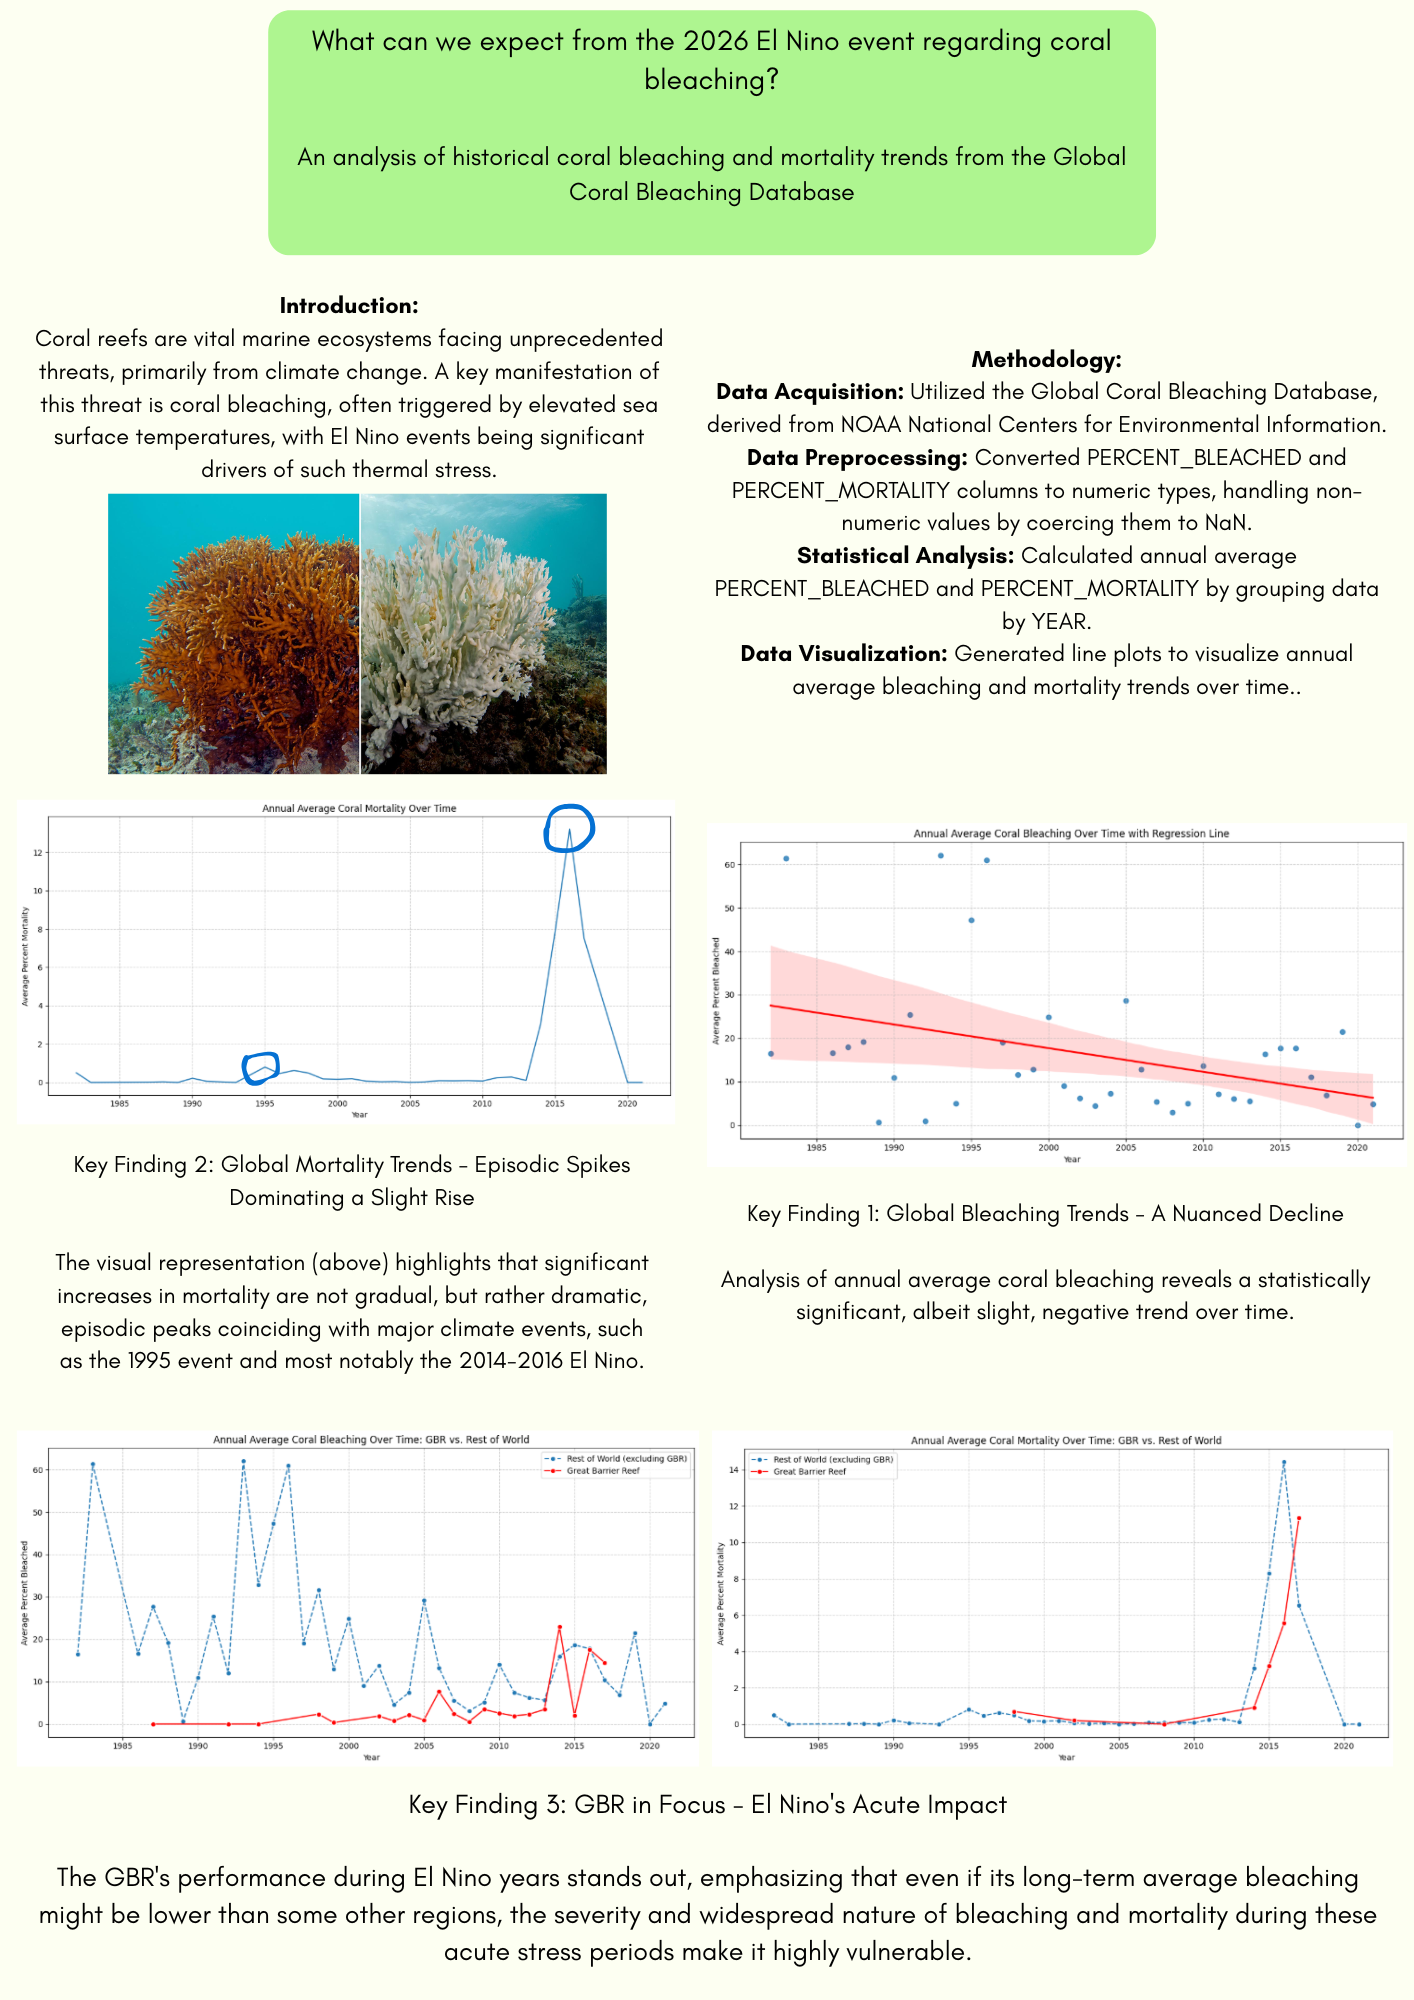

Reflection:

I think the EMSC individual assignment was an extremely beneficial assignment to have undertaken and an informative experience overall. One of my first thoughts about the assignment was that it was going to be interesting doing all the roles in the group assignments by myself. Another one had to do with the Data Science Fair part of the assignment as I knew that I get anxious presenting to others. The first problem I ran into during this assignment was at the very start of completing it. This problem had to do with finding and picking out a dataset as I found the task quite difficult. I knew that I wanted my topic to be something within the study of Marine Science, but I wasn’t sure how to narrow down a specific topic. In the end, I decided to research a variety of topics within my chosen field of interest until I came across a dataset that I felt I would be comfortable to work with. This dataset was the Global Coral Bleaching Dataset, and I was pleased to find that it wouldn’t need any cleaning in Excel. After I had found my dataset, I was having a bit of trouble trying to figure out what research question I was going to do my individual project on so I decided to ask Gemini some prompting questions about the dataset to see what it would suggest. One of these prompting questions was what analysis Gemini would suggest I do with the dataset required. This is how I came across the OLS Regression Results and the code to obtain it. This statistics code was completely new to me and something that hadn’t done before in class but as I was also takin a statistics course, I thought this new code would be more comfortable for me to code and analyse compared to what we were shown in class. After getting some assistance from Dave, I was able to lock down the research question I was going to do and get on with creating graphs and linear regression models. The creation of the graphs for this assignment was one of my favourite parts of the task as I enjoyed playing around with styles and colours, especially with the feedback I received from the Data Science Fair, as well as seeing what I could create with the data at my disposal. Another part of the creation process I really enjoyed was thinking about the analysis for my code and graphs and writing up the narrative that would go along with it. I really enjoyed this part because it allowed me to write deeply about something I was passionate about and format my project in a way that would come across as a real scientific project. I also ended up enjoying presenting my work at the Science Fair and listening to the projects of other people in the class as everyone had such good projects and there was a large variety of topics. Overall, I think this individual project provided me with a lot of valuable tools I can use in the future and while I struggled with it at times, I enjoyed completing it.